# 🏙️ Dataset 1: Intel Image Classification — Custom CNN
## Kỹ thuật: Custom CNN + Data Augmentation

**Pipeline:** Dataset Analysis → Sample Visualization → Augmentation → Build CNN → Train → Evaluate

---

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

import random

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.titleweight': 'bold'})

TRAIN_DIR = '../data/intel_images/seg_train/seg_train'
TEST_DIR  = '../data/intel_images/seg_test/seg_test'
SAVE_DIR  = '../results/intel'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE   = (150, 150)
BATCH_SIZE = 32
EPOCHS     = 30

print(f'TF version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

2026-05-28 10:20:34.268592: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-28 10:20:34.298513: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-28 10:20:34.794389: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TF version: 2.13.0
GPU available: []


2026-05-28 10:20:36.430238: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-28 10:20:36.435847: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-28 10:20:36.438352: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

## 📊 1. Khám phá Dataset

In [2]:
# Count samples per class
classes = sorted(os.listdir(TRAIN_DIR))
train_counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes}
test_counts  = {c: len(os.listdir(os.path.join(TEST_DIR, c)))  for c in classes}

print('=== DATASET OVERVIEW ===')
print(f'Classes ({len(classes)}): {classes}')
print(f'Total Train: {sum(train_counts.values()):,}')
print(f'Total Test : {sum(test_counts.values()):,}')
print('\nPer-class:')
for c in classes:
    print(f'  {c:15s}: Train={train_counts[c]:,}  Test={test_counts[c]:,}')

=== DATASET OVERVIEW ===
Classes (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Total Train: 14,034
Total Test : 3,000

Per-class:
  buildings      : Train=2,191  Test=437
  forest         : Train=2,271  Test=474
  glacier        : Train=2,404  Test=553
  mountain       : Train=2,512  Test=525
  sea            : Train=2,274  Test=510
  street         : Train=2,382  Test=501


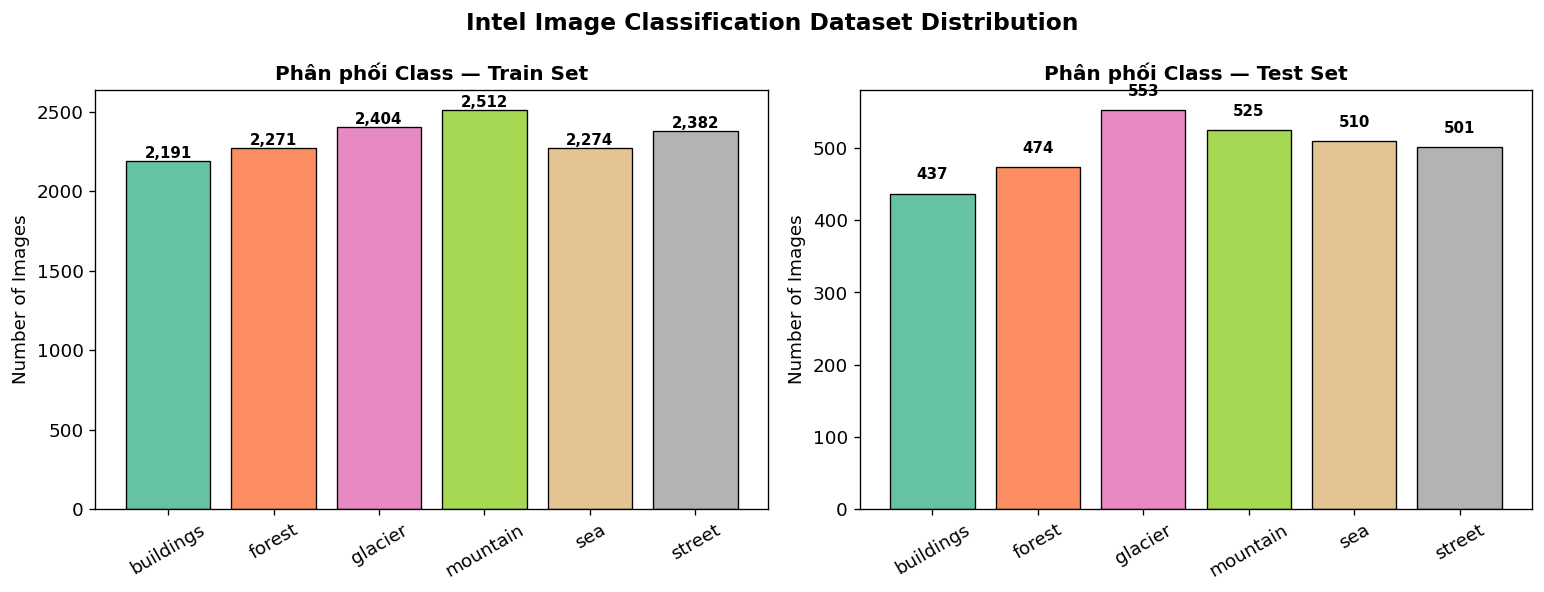

In [3]:
# Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (counts, split) in zip(axes, [(train_counts, 'Train'), (test_counts, 'Test')]):
    bars = ax.bar(counts.keys(), counts.values(),
                  color=plt.cm.Set2(np.linspace(0, 1, len(counts))),
                  edgecolor='black', linewidth=0.8)
    ax.set_title(f'Phân phối Class — {split} Set')
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                f'{val:,}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Intel Image Classification Dataset Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_class_distribution.png', bbox_inches='tight')
plt.show()

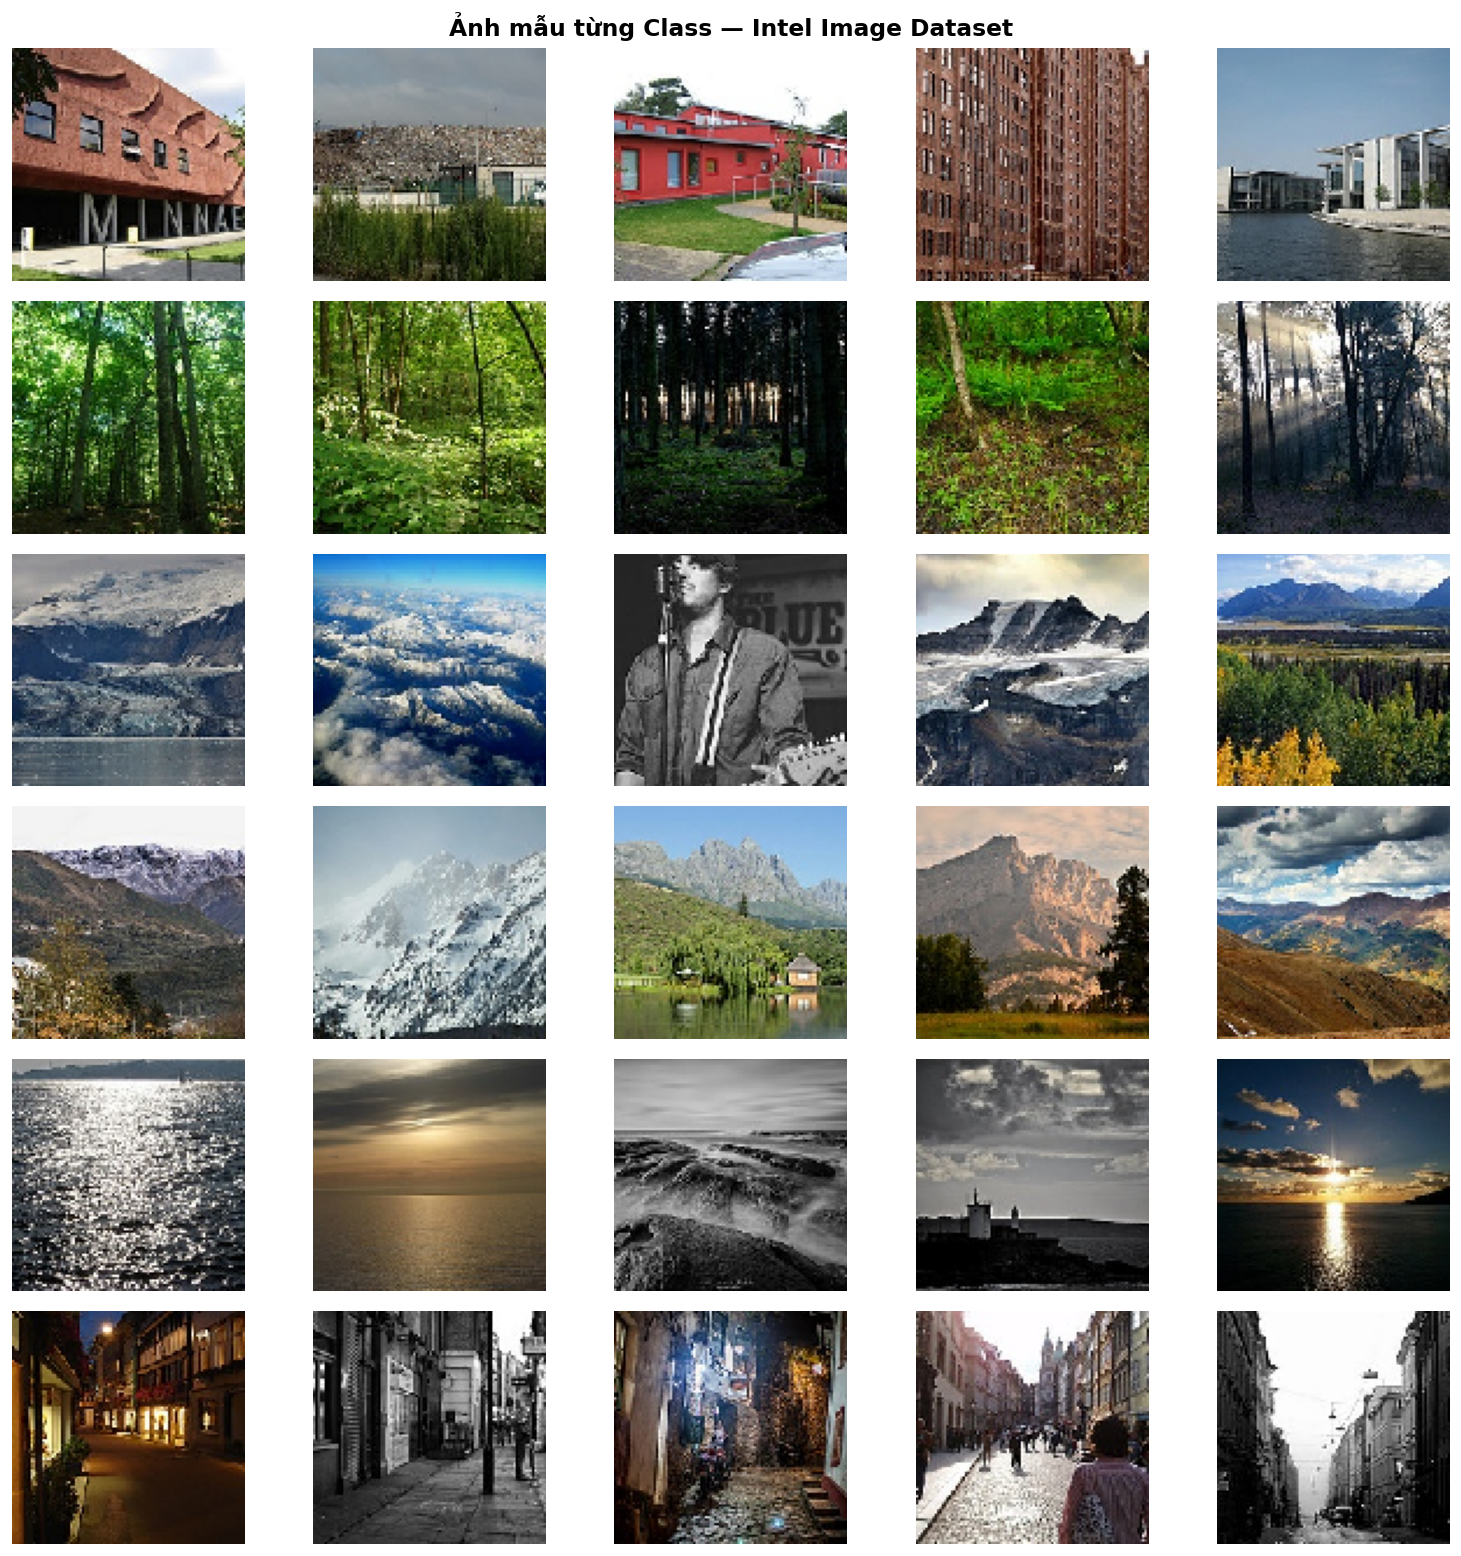

In [4]:
# Show sample images
fig, axes = plt.subplots(len(classes), 5, figsize=(13, len(classes)*2.2))

for row, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    imgs    = os.listdir(cls_dir)[:5]
    for col, img_name in enumerate(imgs):
        img = load_img(os.path.join(cls_dir, img_name), target_size=(100, 100))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, rotation=0, labelpad=50,
                                      fontsize=10, fontweight='bold')

plt.suptitle('Ảnh mẫu từng Class — Intel Image Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_sample_images.png', bbox_inches='tight')
plt.show()

## 🔄 2. Data Augmentation Visualization

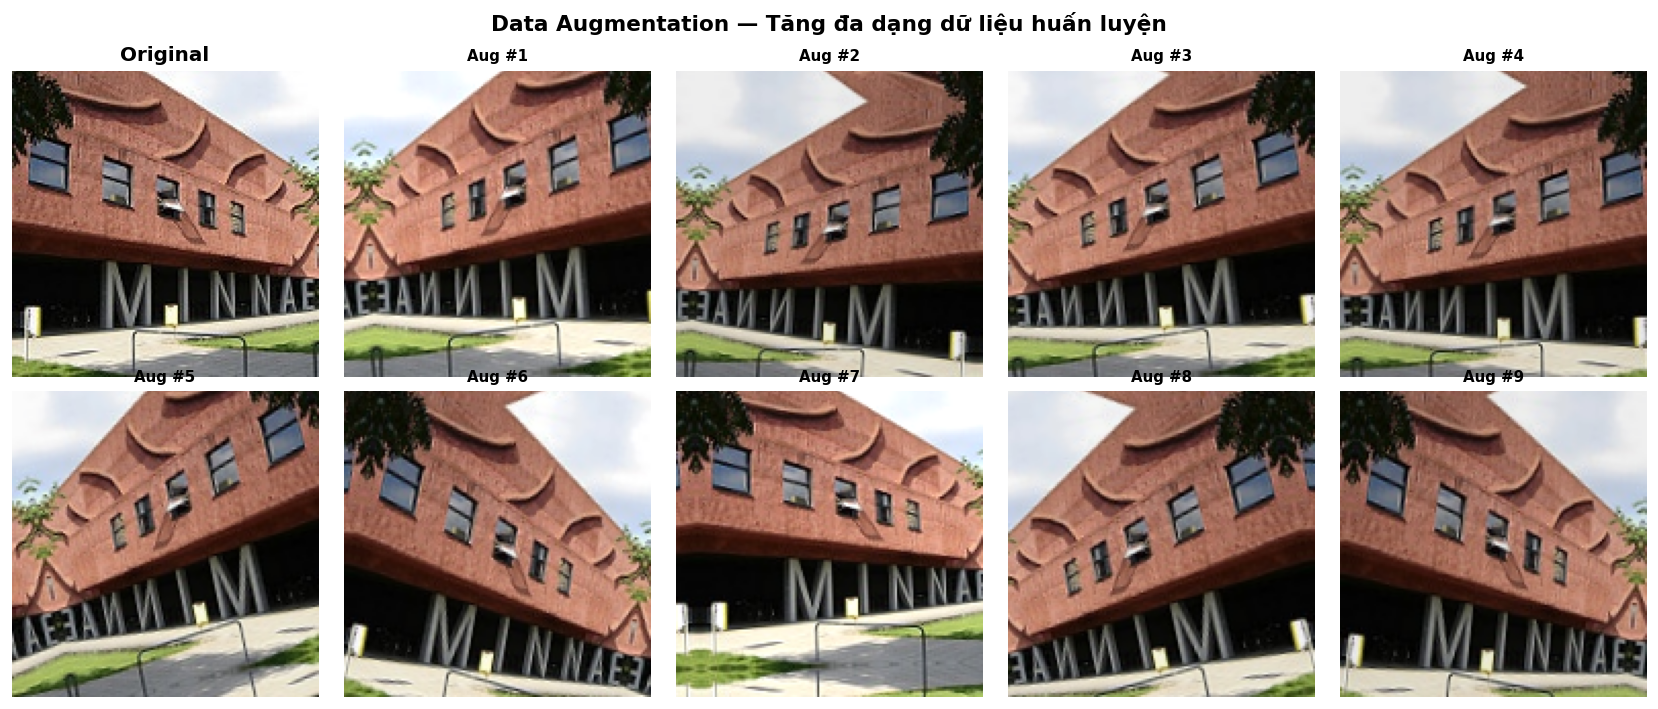

In [5]:
# Show augmentation effect
sample_cls = classes[0]
sample_img_path = os.path.join(TRAIN_DIR, sample_cls,
                                os.listdir(os.path.join(TRAIN_DIR, sample_cls))[0])
sample_img = load_img(sample_img_path, target_size=IMG_SIZE)
# sample_arr = img_to_array(sample_img) / 255.0
sample_arr = img_to_array(sample_img)
sample_arr = np.expand_dims(sample_arr, axis=0)

aug = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    horizontal_flip=True,
    brightness_range=[0.9,1.1],
    fill_mode='reflect'
)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes[0,0].imshow(sample_arr[0].astype(np.uint8))
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

aug_gen = aug.flow(sample_arr, batch_size=1)
for i, ax in enumerate(axes.flatten()[1:]):
    # aug_img = next(aug_gen)[0]
    aug_img = next(aug_gen)[0].astype(np.uint8)
    # aug_img = np.clip(aug_img, 0, 1)
    ax.imshow(aug_img)
    # ax.imshow(aug_img.astype(np.uint8))
    ax.set_title(f'Aug #{i+1}', fontsize=9)
    ax.axis('off')

plt.suptitle('Data Augmentation — Tăng đa dạng dữ liệu huấn luyện', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_augmentation_demo.png', bbox_inches='tight')
plt.show()

## 🏗️ 3. Xây dựng Custom CNN

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    # rotation_range=20,
    # width_shift_range=0.2,
    # height_shift_range=0.2,
    # zoom_range=0.15,
    # horizontal_flip=True,
    # fill_mode='reflect'
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    horizontal_flip=True,
    brightness_range=[0.9,1.1],
    fill_mode='reflect'
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical',
    seed=SEED)
test_gen  = test_datagen.flow_from_directory(
    TEST_DIR,  target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical',
    seed=SEED,
    shuffle=False)

NUM_CLASSES = len(classes)
print(f'Classes       : {train_gen.class_indices}')
print(f'Num Classes   : {NUM_CLASSES}')
print(f'Train Samples : {train_gen.samples}')
print(f'Test Samples  : {test_gen.samples}')

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Classes       : {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Num Classes   : 6
Train Samples : 14034
Test Samples  : 3000


In [7]:
model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(150,150,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='CustomCNN_Intel')

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "CustomCNN_Intel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 150, 150, 32)      128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 150, 150, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 75, 75, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 75, 75, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 75, 75, 64)    

## 🚀 4. Training

In [8]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
 41/439 [=>............................] - ETA: 1:09 - loss: 1.6275 - accuracy: 0.4680

439/439 [==============================] - 80s 182ms/step - loss: 1.1695 - accuracy: 0.5830 - val_loss: 4.2783 - val_accuracy: 0.2230 - lr: 0.0010
Epoch 2/30
439/439 [==============================] - 80s 182ms/step - loss: 0.8341 - accuracy: 0.6975 - val_loss: 0.7959 - val_accuracy: 0.7083 - lr: 0.0010
Epoch 3/30
439/439 [==============================] - 79s 181ms/step - loss: 0.7060 - accuracy: 0.7363 - val_loss: 0.6707 - val_accuracy: 0.7563 - lr: 0.0010
Epoch 4/30
439/439 [==============================] - 79s 181ms/step - loss: 0.6119 - accuracy: 0.7820 - val_loss: 0.6814 - val_accuracy: 0.7570 - lr: 0.0010
Epoch 5/30
439/439 [==============================] - 79s 180ms/step - loss: 0.5642 - accuracy: 0.7948 - val_loss: 0.7488 - val_accuracy: 0.7660 - lr: 0.0010
Epoch 6/30
439/439 [==============================] - ETA: 0s - loss: 0.5603 - accuracy: 0.7986
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
439/439 [==============================] - 79s 18

## 📈 5. Phân tích Kết quả

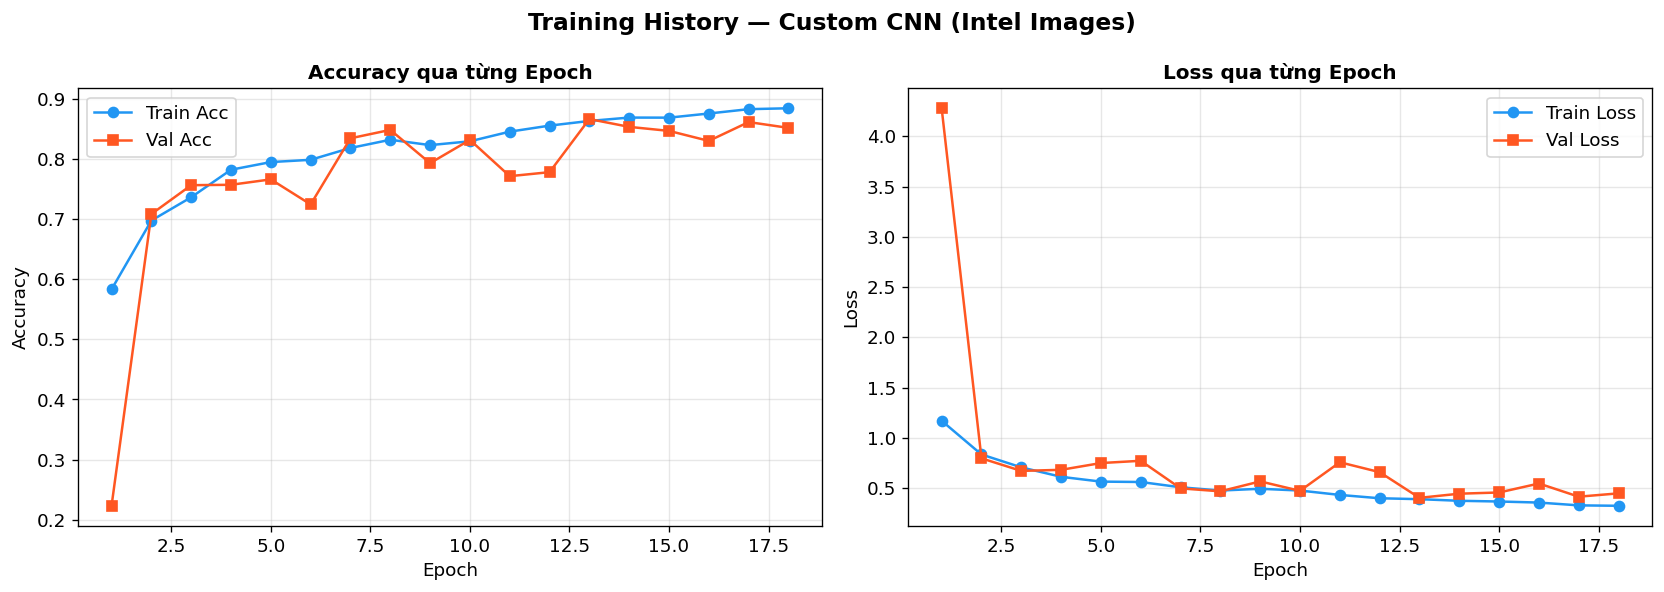


✅ Best Validation Accuracy: 0.8663


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history['accuracy'])+1)

axes[0].plot(epochs_range, history.history['accuracy'],    'o-', color='#2196F3', label='Train Acc')
axes[0].plot(epochs_range, history.history['val_accuracy'],'s-', color='#FF5722', label='Val Acc')
axes[0].set_title('Accuracy qua từng Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history['loss'],    'o-', color='#2196F3', label='Train Loss')
axes[1].plot(epochs_range, history.history['val_loss'],'s-', color='#FF5722', label='Val Loss')
axes[1].set_title('Loss qua từng Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — Custom CNN (Intel Images)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_training_history.png', bbox_inches='tight')
plt.show()

best_val_acc = max(history.history['val_accuracy'])
print(f'\n✅ Best Validation Accuracy: {best_val_acc:.4f}')

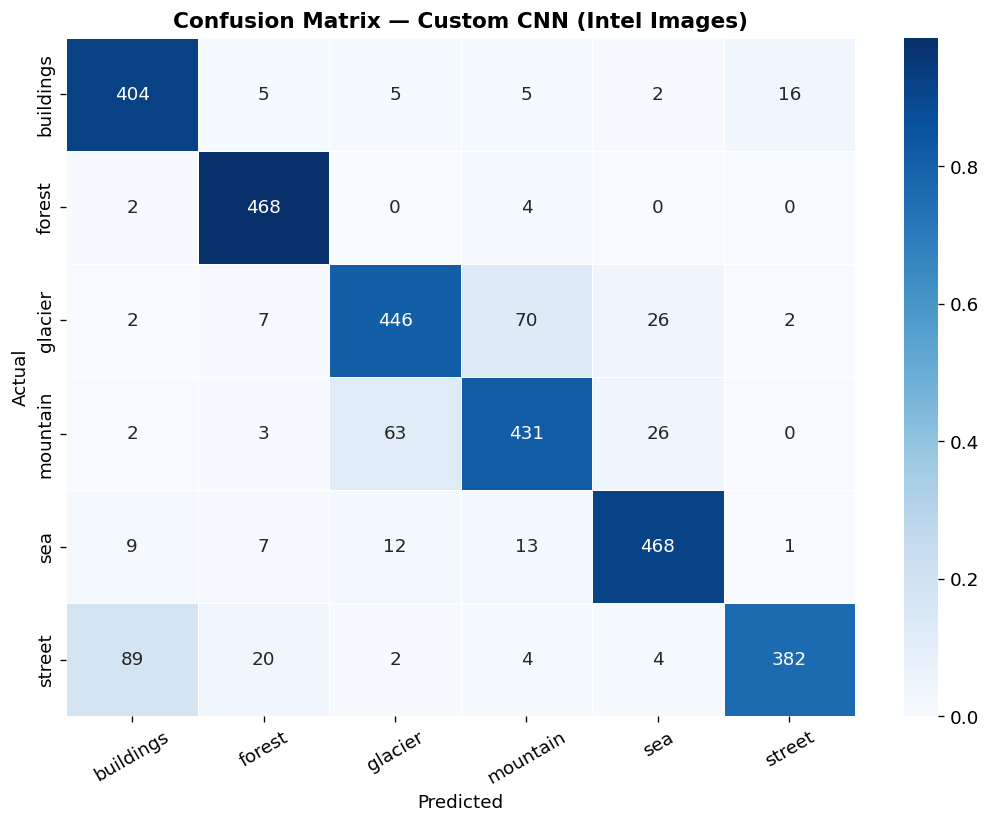

              precision    recall  f1-score   support

   buildings       0.80      0.92      0.86       437
      forest       0.92      0.99      0.95       474
     glacier       0.84      0.81      0.83       553
    mountain       0.82      0.82      0.82       525
         sea       0.89      0.92      0.90       510
      street       0.95      0.76      0.85       501

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



In [10]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(9, 7))
import seaborn as sns
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — Custom CNN (Intel Images)', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(classification_report(y_true, y_pred, target_names=classes))

In [11]:
# Save report
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Intel Images Classification — Custom CNN\n' + '='*50 + '\n')
    f.write(f'Best Validation Accuracy: {best_val_acc:.4f}\n')
    f.write(f'Total Parameters: {model.count_params():,}\n\n')
    f.write(classification_report(y_true, y_pred, target_names=classes))

print('✅ Intel CNN Experiment Completed! Results saved to', SAVE_DIR)

✅ Intel CNN Experiment Completed! Results saved to ../results/intel
